# Masterclass 1a: The State of the Union corpus

Every State of the Union address from 1790 to 2026, and what the corpus looks like taken as a whole.

## Today's goal

1. Load every State of the Union address (1790 to 2026) into a pandas DataFrame.
2. Look at individual speeches and summarise the metadata.
3. Plot speech length across two centuries, coloured by party.
4. Build a document-feature matrix: counts of every word in every speech.
5. Draw a word cloud of the most frequent corpus-wide terms.
6. Discover hidden topics with Latent Dirichlet Allocation.

In [1]:
# Libraries used throughout the notebook.
import re
import sotu
import pandas
import matplotlib.pyplot as plt
import sklearn.feature_extraction.text
import sklearn.decomposition
import scipy.spatial.distance
import scipy.cluster.hierarchy
import wordcloud
import nltk.stem
import seaborn
import plotly.express
from corpus_tools import comparison_cloud, linear_band, loess_band

print('Libraries imported.')

Libraries imported.


The `sotu` library exposes every U.S. State of the Union address from 1790 to 2026 as a pandas DataFrame. Each row is one speech.

In [2]:
df = sotu.load()
print(f'{len(df)} speeches, {df["year"].min()} to {df["year"].max()}.')
df[['year', 'president', 'party', 'sotu_type']].head(3)

237 speeches, 1790 to 2026.


,year,president,party,sotu_type
0,1790,Washington,Nonpartisan,spoken
1,1790,Washington,Nonpartisan,spoken
2,1791,Washington,Nonpartisan,spoken


In [3]:
# Same data, the most recent few addresses.
df[['year', 'president', 'party', 'sotu_type']].tail(3)

,year,president,party,sotu_type
234,2023,Biden,Democratic,spoken
235,2024,Biden,Democratic,spoken
236,2026,Trump,Republican,spoken


Washington's first address. The `text` column holds the full speech as a single string.

Square brackets holding a colon take a slice, meaning a piece of something. `[:600]` takes the first 600 characters, `[-10:]` would take the last ten, and `[::-1]` steps backwards through the whole thing. Lists slice the same way.

`df.iloc[0]` takes a whole row by its position, counting from zero, so this is the first speech and `df.iloc[1]` would be the second. The row arrives with every column attached.

In [4]:
first = df.iloc[0]
print(f'{first["year"]} {first["president"]}')
print(first['text'][:600] + ' ...')

1790 Washington
Fellow-Citizens of the Senate and House of Representatives:

I embrace with great satisfaction the opportunity which now presents itself of congratulating you on the present favorable prospects of our public affairs. The recent accession of the important state of North Carolina to the Constitution of the United States (of which official information has been received), the rising credit and respectability of our country, the general and increasing good will toward the government of the Union, and the concord, peace, and plenty with which we are blessed are circumstances auspicious in an eminent ...


In [5]:
# Washington's second address.
second = df.iloc[1]
print(f'{second["year"]} {second["president"]}')
print(second['text'][:600] + ' ...')

1790 Washington
Fellow-Citizens of the Senate and House of Representatives:

In meeting you again I feel much satisfaction in being able to repeat my congratulations on the favorable prospects which continue to distinguish our public affairs. The abundant fruits of another year have blessed our country with plenty and with the means of a flourishing commerce.

The progress of public credit is witnessed by a considerable rise of American stock abroad as well as at home, and the revenues allotted for this and other national purposes have been productive beyond the calculations by which they were regulated. This ...


In [6]:
# Metadata at a glance: column names and types.
df.dtypes

year         int64
president      str
party          str
sotu_type      str
text           str
dtype: object

In [7]:
# How many speeches per party.
df['party'].value_counts()

party
Democratic               93
Republican               92
Democratic-Republican    28
Nonpartisan               8
Whig                      8
Federalist                4
National Union            4
Name: count, dtype: int64

Inside an f-string, a colon within the braces says *how* to print a value rather than which value to print.

Putting `:,` after the colon groups thousands, so 2007679 prints as 2,007,679.

In [8]:
# Speech length per address: tokens approximated by whitespace splitting.
df['tokens'] = df['text'].str.split().str.len()

print(f'{df["tokens"].sum():,} tokens across the whole corpus.')
df[['year', 'president', 'tokens']].head(5)

1,980,427 tokens across the whole corpus.


,year,president,tokens
0,1790,Washington,1090
1,1790,Washington,1408
2,1791,Washington,2146
3,1792,Washington,2098
4,1793,Washington,1965


How you split text into words is a decision, not a fact, and every number after it depends on the choice. Splitting on whitespace leaves punctuation attached, so 'Union,' and 'Union' count as two different words.

Matching runs of letters and digits instead throws the punctuation away and counts them as one. Later notebooks split that second way, which is why their corpus totals differ from the number above.

In [9]:
sample = 'The State of the Union is strong, and the Union endures.'
print('whitespace:', sample.split())
print('letters   :', re.findall(r'\w+', sample))

whitespace: ['The', 'State', 'of', 'the', 'Union', 'is', 'strong,', 'and', 'the', 'Union', 'endures.']
letters   : ['The', 'State', 'of', 'the', 'Union', 'is', 'strong', 'and', 'the', 'Union', 'endures']


Before the picture, the traditional way to report this. Fit a straight line, then print the regression table that journals have asked for since long before anyone could put a corpus on a laptop.

Read it and answer one question: has the State of the Union got longer or shorter since 1790?

In [10]:
grid, fitted, lower, upper, straight_line = linear_band(df['year'], df['tokens'])
print(straight_line.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1230
Date:                Wed, 29 Jul 2026   Prob (F-statistic):              0.726
Time:                        16:36:04   Log-Likelihood:                -2397.2
No. Observations:                 237   AIC:                             4798.
Df Residuals:                     235   BIC:                             4805.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4494.3341    1.1e+04      0.408      0.6

One point per speech, coloured by party. Speeches are separate events, so there is no line joining them: a line would slope across the years between two addresses and imply measurements nobody took.

Two fits, drawn together. The dashed line is the straight one least squares gives. The solid curve is a loess smoother, which follows the data locally instead of committing to one slope across two centuries.

Every scatter in this course is drawn with seaborn, which sits on top of matplotlib and understands DataFrames. Plots seaborn does not do, the networks and the word clouds, stay with matplotlib throughout.

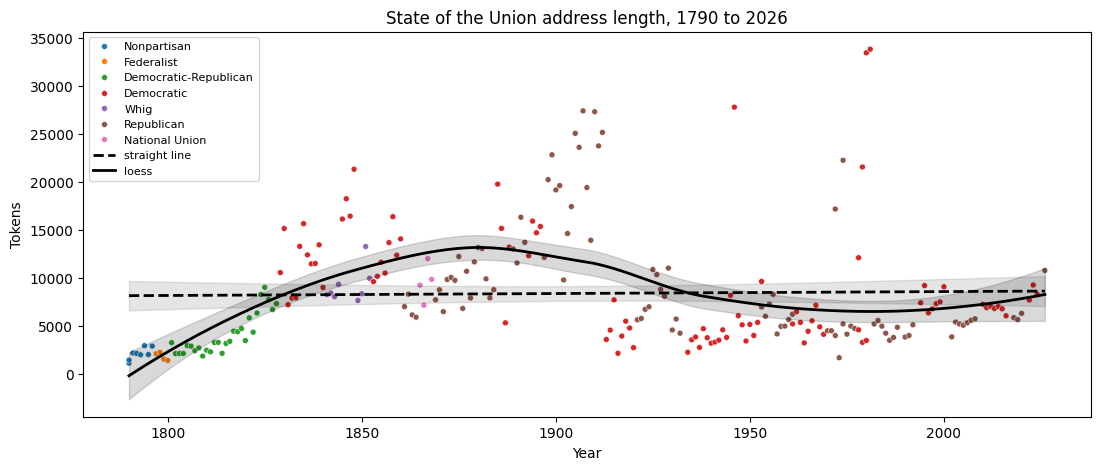

In [11]:
plt.figure(figsize=(13, 5))
axes = seaborn.scatterplot(data=df, x='year', y='tokens', hue='party', s=18)
linear_band(df['year'], df['tokens'], ax=axes, label='straight line')
loess_band(df['year'], df['tokens'], ax=axes, label='loess')
axes.set(xlabel='Year', ylabel='Tokens',
         title='State of the Union address length, 1790 to 2026')
axes.legend(loc='upper left', fontsize=8)
plt.show()

The table's answer is no. R-squared is 0.001, so the line accounts for one tenth of one percent of the variation, and the slope's p-value of 0.73 says even that much is indistinguishable from chance.

That answer is wrong. Speech length changed enormously, and the line missed it because it rose until about 1880 and fell afterwards. A single slope averages a rise and a fall into nothing.

The straight line runs from 8,121 tokens to 8,599 across the whole corpus. The loess curve climbs to 13,146 by 1880 and comes back to 8,244 by 2026. Same data, same 95% confidence, opposite stories.

The picture shows in a second what the table hid behind twenty-five lines of diagnostics. Neither fit is lying. The straight one was asked the wrong question, and answered it honestly.

The loess is not magic. At 1790 its curve dips below zero, which no speech can do. That is the smoother running out of neighbours at the edge of the corpus, and it is left visible rather than tidied away.

matplotlib draws a picture. plotly builds a small interactive web page, so the same data can answer a question the static plot leaves hanging: which speech is that outlier, and who gave it?

Hover any point for the president, the year, the length, and whether the address was spoken or written. Click a party in the legend to hide it, and double-click a party to show that one alone.

In [12]:
figure = plotly.express.scatter(
    df,
    x='year',
    y='tokens',
    color='party',
    hover_name='president',
    hover_data=['sotu_type'],
)
figure.show()

A document-feature matrix (DFM) holds the count of every word in every document. `CountVectorizer` from scikit-learn builds one in a single call, with English stop-word removal built in.

In [13]:
vectorizer = sklearn.feature_extraction.text.CountVectorizer(
    lowercase=True,
    stop_words='english',
)
dfm = vectorizer.fit_transform(df['text'])
features = vectorizer.get_feature_names_out()
labels = (df['year'].astype(str) + ' ' + df['president']).tolist()

print(f'DFM: {dfm.shape[0]} speeches by {dfm.shape[1]} unique features.')

DFM: 237 speeches by 26013 unique features.


In [14]:
# Top 20 features across the whole corpus.
dfm_df = pandas.DataFrame(dfm.toarray(), index=labels, columns=features)
corpus_totals = dfm_df.sum(axis=0).sort_values(ascending=False)
corpus_totals.head(20)

government    7629
states        6948
congress      5821
united        5170
year          4839
people        4458
country       3727
new           3534
great         3494
public        3408
000           3218
time          3180
american      3014
war           2952
world         2842
years         2725
national      2428
nation        2395
state         2375
law           2366
dtype: int64

Eleventh on that list is `000`, which is not a word. The pattern that splits text into words breaks on punctuation and drops single characters, so a figure like $50,000 leaves `000` behind on its own.

It survives into the topic model further down, where it turns up among a topic's leading words. Tokenising is a decision about what counts as a word, and this is what one made carelessly looks like.

The word cloud needs the counts as a dictionary. A dictionary stores pairs: a key, and the value that key points to. Here every key is a word and every value is how often the corpus uses it.

You look a value up by its key, in square brackets, rather than by position. So `frequencies['government']` finds that word's total wherever it happens to sit.

In [15]:
frequencies = corpus_totals.to_dict()

print(f'{len(frequencies):,} word-to-count pairs.')
print(frequencies['government'])
print(frequencies['congress'])

26,013 word-to-count pairs.
7629
5821


Building one works the other way round. Start with an empty dictionary, written `{}`, then assign a value to each key. The topic-model helper further down does exactly this.

In [16]:
top_three = {}
for word, count in corpus_totals.head(3).items():
    top_three[word] = count

print(top_three)

{'government': 7629, 'states': 6948, 'congress': 5821}


A dictionary answers "what is the count for this word". It will not answer "what is the third word", because the way in is the key rather than a position.

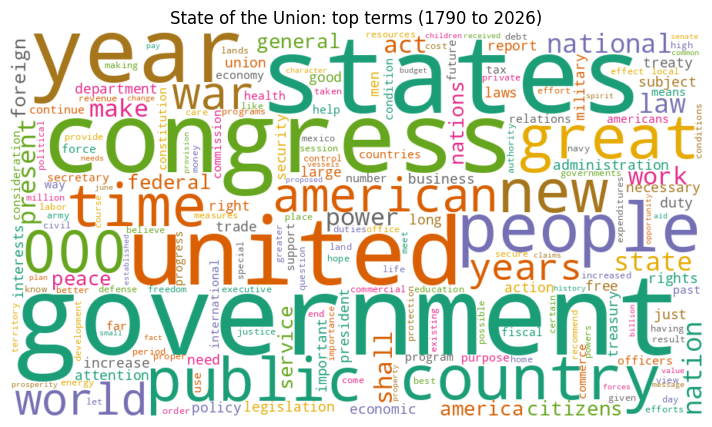

In [17]:
# Word cloud of the corpus-wide top terms.
wc = wordcloud.WordCloud(
    width=900,
    height=500,
    background_color='white',
    colormap='Dark2',
    random_state=42,
).generate_from_frequencies(frequencies)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('State of the Union: top terms (1790 to 2026)')
plt.show()

Why stem at all? In the unstemmed matrix every word form is its own feature, so a single idea is split across many columns. The variants of 'nation' below each carry a separate count, and stemming rewrites them to a shared root.

Reference: [NLTK's stemmer documentation](https://www.nltk.org/howto/stem.html).

`:16s` pads a word out to sixteen characters with spaces, so what follows starts in the same column on every line instead of wandering left and right.

`:5d` does the same for a whole number, padding it to five characters. The `d` says the value being printed is a whole number.

In [18]:
demo_stemmer = nltk.stem.SnowballStemmer('english')
nation_like = []
for word in features:
    if word.startswith('nation'):
        nation_like.append(word)

distinct_roots = []
for word in nation_like:
    root = demo_stemmer.stem(word)
    if root not in distinct_roots:
        distinct_roots.append(root)
    print(f'{word:16s} count {int(corpus_totals[word]):5d}   ->  {root}')

print(f'{len(nation_like)} separate features reduce to {len(distinct_roots)} root(s) after stemming.')

nation           count  2395   ->  nation
national         count  2428   ->  nation
nationalism      count     6   ->  nation
nationalist      count     4   ->  nationalist
nationalities    count     9   ->  nation
nationality      count    19   ->  nation
nationalized     count     2   ->  nation
nationalizes     count     1   ->  nation
nationally       count    10   ->  nation
nationals        count    16   ->  nation
nations          count  1955   ->  nation
nationwide       count    23   ->  nationwid
12 separate features reduce to 3 root(s) after stemming.


Build the stemmed, trimmed matrix that the topic model and the dendrograms will use. Stemming merges the variants we just saw into one root, and trimming drops words too rare to carry clustering signal.

The word cloud and top-feature lists above keep the full, unstemmed words, so nothing already drawn changes.

This is our first function. `def` gives it a name and lists what it needs, and `return` hands the answer back. Nothing happens until we call it. `' '.join(roots)` glues a list of words into one string with a space between each pair.

The names a function lists in its brackets are called its arguments. `stem_text` has one, `text`, which stands for whatever you hand it when you call it.

In [19]:
stemmer = nltk.stem.SnowballStemmer('english')

def stem_text(text):
    roots = []
    for word in text.lower().split():
        roots.append(stemmer.stem(word))
    return ' '.join(roots)

# Try it on one sentence before turning it loose on 237 speeches.
print(stem_text('The nations of the world debated national policies.'))

the nation of the world debat nation policies.


Now run that function over every speech. The loop is the same shape we have used all along, and the only new part is that the work inside is a function we wrote ourselves.

In [20]:
stemmed_docs = []
for text in df['text']:
    stemmed_docs.append(stem_text(text))

print(f'{len(stemmed_docs)} speeches stemmed.')

237 speeches stemmed.


Count the stemmed text into a matrix, the same way we did with the raw text earlier. `min_df=3` tells CountVectorizer to ignore any word appearing in fewer than three speeches.

In [21]:
stem_vectorizer = sklearn.feature_extraction.text.CountVectorizer(
    stop_words='english',
    min_df=3,
)
stem_counts = stem_vectorizer.fit_transform(stemmed_docs).toarray()
stem_features = stem_vectorizer.get_feature_names_out()

print(f'Stemmed matrix: {stem_counts.shape[0]} speeches by {stem_counts.shape[1]:,} features.')

Stemmed matrix: 237 speeches by 12,732 features.


Trim the rare words. Comparing the totals against 5 gives a list of True and False, one per column, saying whether that word clears the threshold.

Handing that list back as an index keeps only the columns marked True, for the counts and their names alike.

In [22]:
column_totals = stem_counts.sum(axis=0)
keep = column_totals >= 5
stem_counts = stem_counts[:, keep]
stem_features = stem_features[keep]

print(f'After trimming: {stem_counts.shape[0]} speeches by {stem_counts.shape[1]:,} features.')

After trimming: 237 speeches by 10,173 features.


Latent Dirichlet Allocation finds clusters of words that tend to co-occur across documents. Each cluster is a topic, and each speech is a mixture of topics.

`top_topics` runs one model and lists each topic's leading words, tagged with that topic's document mass, meaning how many speeches' worth of weight it carries. Written once and reused for both runs below.

`enumerate` walks a list and hands back two things each time round: the position, counting from zero, and the item sitting there. Without it you would have to keep count yourself.

`:.1f` prints a number with one digit after the decimal point, rounded. The `:.0f` and `:.3f` further down are the same thing asking for no digits and for three.

In [23]:
def top_topics(model):
    document_mass = model.transform(stem_counts).sum(axis=0)
    topics = {}
    for topic_index, weights in enumerate(model.components_):
        positions_by_weight = weights.argsort()
        strongest_positions = positions_by_weight[-10:]
        top_indices = strongest_positions[::-1]
        top_words = []
        for word_index in top_indices:
            top_words.append(stem_features[word_index])
        label = f'Topic {topic_index + 1} (mass {document_mass[topic_index]:.1f})'
        topics[label] = top_words
    return pandas.DataFrame(topics)

Run it on the stemmed, trimmed matrix, so the topic words come out as roots. The number of topics is a choice. Start with eight, and read the mass tagged on each column.

Reference: [scikit-learn on Latent Dirichlet Allocation](https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda).

In [24]:
lda8 = sklearn.decomposition.LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    max_iter=20,
).fit(stem_counts)
top_topics(lda8)

,Topic 1 (mass 24.5),Topic 2 (mass 40.1),Topic 3 (mass 17.4),Topic 4 (mass 99.1),Topic 5 (mass 17.0),Topic 6 (mass 0.0),Topic 7 (mass 0.0),Topic 8 (mass 38.8)
0,year,nation,000,state,law,consign,consign,america
1,program,world,year,unit,govern,license,license,american
2,nation,war,govern,govern,ani,wished,wished,year
3,feder,peopl,unit,congress,public,shelf,shelf,work
4,congress,great,dure,public,work,refut,refut,new
5,new,free,state,ani,state,1823,1823,peopl
6,increas,power,increas,great,great,directions,directions,make
7,continu,time,american,nation,congress,prestig,prestig,world
8,govern,peac,congress,power,nation,readiness,readiness,help
9,develop,onli,report,year,countri,judicial,judicial,nation


## Eight topics is too many

Two of these topics are identical and own almost no speeches. Eight topics is more than this corpus supports. The surplus topics find no documents, so they collapse onto the same handful of rare words. Choosing the number of topics is a real modelling decision.

Further reading: [scikit-learn's LDA guide](https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda) and [Wallach, Mimno & McCallum (2009), *Rethinking LDA: Why Priors Matter*](https://papers.nips.cc/paper/3854-rethinking-lda-why-priors-matter), which shows how better priors make topic models robust to this choice.

In [25]:
# Five topics. Every topic now owns real document weight and the duplicates are gone.
lda5 = sklearn.decomposition.LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=20,
).fit(stem_counts)
top_topics(lda5)

,Topic 1 (mass 37.4),Topic 2 (mass 51.9),Topic 3 (mass 25.4),Topic 4 (mass 98.3),Topic 5 (mass 23.9)
0,nation,american,000,state,nation
1,year,america,year,unit,ani
2,program,year,govern,govern,law
3,congress,peopl,state,congress,great
4,feder,world,unit,public,govern
5,new,new,congress,ani,men
6,world,work,law,great,onli
7,increas,nation,dure,nation,public
8,govern,make,increas,power,work
9,continu,everi,american,year,power


## What we've covered

**Python**

- library imports
- pandas DataFrame inspection and column assignment
- `.iloc` for taking a row by position
- boolean masking
- `for` loops
- `enumerate` for position and item together
- dictionaries: keys, values, and building one by assignment
- writing our own function with `def` and `return`
- f-strings, and the format specs `:,`, `:16s`, `:5d` and `:.1f`
- importing a helper from a local module

**Corpus linguistics**

- loading a built-in corpus
- document-feature matrix
- English stop-word filtering
- corpus-wide top features, and what a tokeniser leaves behind
- word clouds
- stemming to merge word variants
- Latent Dirichlet Allocation, and the effect of choosing the number of topics

Next: `1b-sotu-by-speech.ipynb`, which turns from the corpus as a whole to the individual speeches, and asks which ones resemble each other.